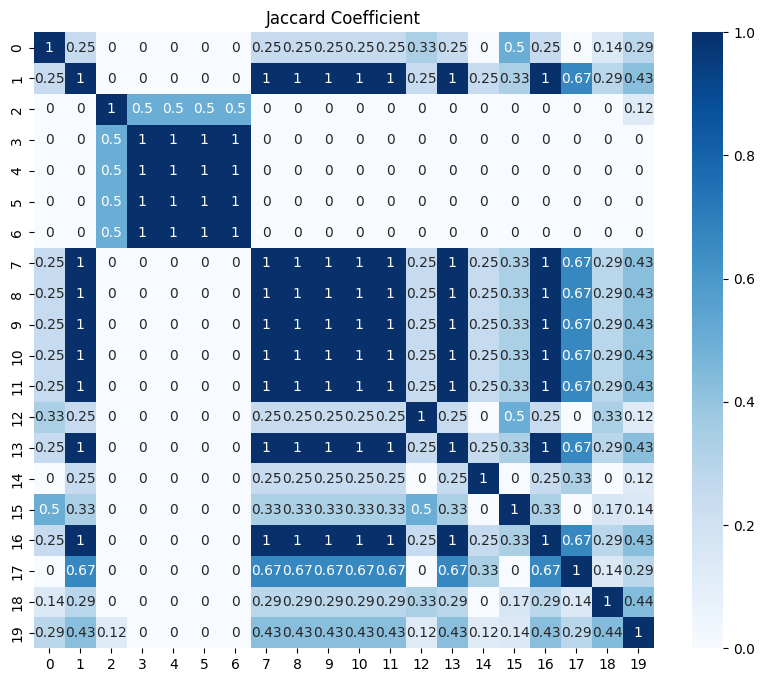

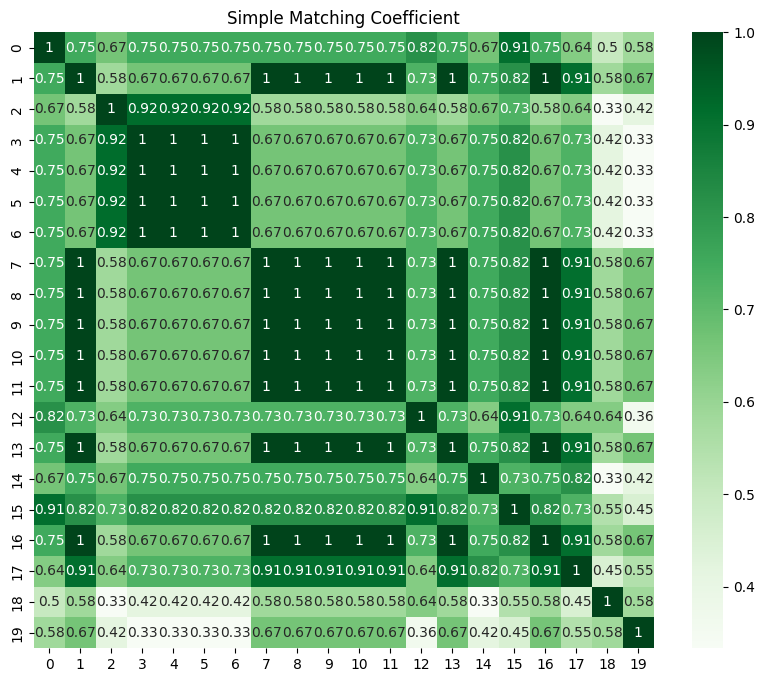

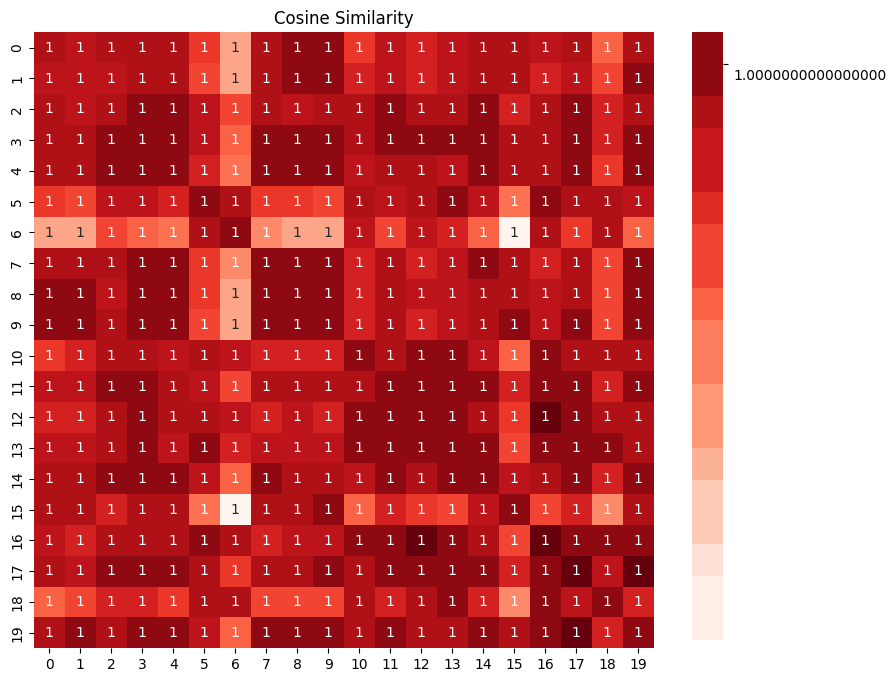

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

file_path = r"C:\Users\Siddharth\Downloads\Lab Session Data.xlsx"

df = pd.read_excel(file_path, sheet_name="thyroid0387_UCI")

mapping = {
    't':1,'f':0,
    'T':1,'F':0,
    'yes':1,'no':0,
    'Yes':1,'No':0,
    True:1,
    False:0
}

df = df.replace(mapping)

df20 = df.iloc[:20]

binary_cols = []

for col in df20.columns:
    unique = df20[col].dropna().unique()

    if len(unique) == 2:
        binary_cols.append(col)

binary = df20[binary_cols]

numeric = df20.select_dtypes(include=np.number)

n = len(df20)

JC = np.zeros((n,n))
SMC = np.zeros((n,n))
COS = np.zeros((n,n))

for i in range(n):

    for j in range(n):

        A = binary.iloc[i]
        B = binary.iloc[j]

        f11=f10=f01=f00=0

        for k in range(len(binary_cols)):

            a=A.iloc[k]
            b=B.iloc[k]

            if a==1 and b==1:
                f11+=1

            elif a==1 and b==0:
                f10+=1

            elif a==0 and b==1:
                f01+=1

            elif a==0 and b==0:
                f00+=1

        if(f11+f10+f01)!=0:
            JC[i,j]=f11/(f11+f10+f01)

        SMC[i,j]=(f11+f00)/(f11+f10+f01+f00)

        x=numeric.iloc[i].fillna(0).to_numpy()
        y=numeric.iloc[j].fillna(0).to_numpy()

        dot=np.dot(x,y)

        normx=np.linalg.norm(x)
        normy=np.linalg.norm(y)

        if normx!=0 and normy!=0:
            COS[i,j]=dot/(normx*normy)

plt.figure(figsize=(10,8))
sns.heatmap(JC,annot=True,cmap="Blues")
plt.title("Jaccard Coefficient")
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(SMC,annot=True,cmap="Greens")
plt.title("Simple Matching Coefficient")
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(COS,annot=True,cmap="Reds")
plt.title("Cosine Similarity")
plt.show()